# 🩺 Démonstration : Pipeline configurable pour analyse de radiographies pulmonaires

Ce notebook illustre la conception d’une architecture modulaire permettant :
- le **chargement automatique de pipelines configurés par JSON**,
- la **construction dynamique de modèles TensorFlow/Keras**,
- l’**entraînement, sauvegarde et rechargement** des modèles,
- la gestion de **plusieurs pipelines concurrents** (EfficientNet, ResNet...).

Les classes de notre dataset :
- Normal
- Covid
- Pneumonia
- Lung Opacity

## 🧭 Schéma d’architecture du système

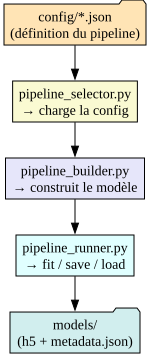

In [1]:
from graphviz import Digraph

g = Digraph('pipeline', format='png')
g.attr(rankdir='UD',ize='7')

g.node('A', 'config/*.json\n(définition du pipeline)', shape='folder', style='filled', fillcolor='#FFE4B5')
g.node('B', 'pipeline_selector.py\n→ charge la config', shape='box', style='filled', fillcolor='#FAFAD2')
g.node('C', 'pipeline_builder.py\n→ construit le modèle', shape='box', style='filled', fillcolor='#E6E6FA')
g.node('D', 'pipeline_runner.py\n→ fit / save / load', shape='box', style='filled', fillcolor='#E0FFFF')
g.node('E', 'models/\n(h5 + metadata.json)', shape='folder', style='filled', fillcolor='#D1EEEE')

g.edges([('A','B'), ('B','C'), ('C','D'), ('D','E')])
g

##

## Chargement Pipeline

In [2]:
import sys
import os
sys.path.append(os.path.abspath("../src"))
from features.Pipe2.pipeline_selector import load_pipeline_config

In [3]:


cfg = load_pipeline_config("pipeline_test.json")
print("✅ Pipeline chargé :", cfg["model"]["base"])

FileNotFoundError: ❌ Fichier config introuvable: Configs_Pipelines\pipeline_test.json